In [28]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K
import sys

#import wandb

In [29]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


In [31]:
# FUNÇÕES
def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [32]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

fine_tunning_train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
fine_tunning_val_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/fine_tunning_oasis'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

In [33]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir_base, f"test_{n}")):
            os.remove(os.path.join(results_dir_base,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir_base, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_4 criada


# Pré-treino

In [ ]:
# Nome das classes
# adni_class_names = ['cn', 'mci', 'ad']
adni_class_names = ['cn', 'ad']
# oasis_class_names = ['0.0', '0.5', '1.0']
oasis_class_names = ['0.0', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

# Experimento 1
train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=True, 
    augmentation_factor=1,      # 1 para 1
    include_intensity=False,    # Só Geometria
    transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
)

# # Experimento 2
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 3
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=1,      # 1 para 1
#     include_intensity=True,     # Geometria + Intensidade
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 4
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=True,     # Geometria + Intensidade
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 5
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=1,      # 1 para 1
#     include_intensity=False,    # Só Geometria
#     transform_probability=0.5   # 50% chance de transformar, 50% de manter original
# )

# # Experimento 6
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=0.5   # 50% chance de transformar, 50% de manter original
# )

print(f"N treino: {len(train_paths)}")

val_images, val_labels, val_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=False
)

print(f"N validation: {len(val_paths)}")

Passo 1: Coletando arquivos e definindo estratégia...
Total de 1064 imagens planejadas.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/1064
Progresso: 200/1064
Progresso: 300/1064
Progresso: 400/1064
Progresso: 500/1064
Progresso: 600/1064
Progresso: 700/1064
Progresso: 800/1064
Progresso: 900/1064
Progresso: 1000/1064
Concluído.
N treino: 1064
Passo 1: Coletando arquivos e definindo estratégia...
Total de 289 imagens planejadas.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/289
Progresso: 200/289
Concluído.
N validation: 289


: 

In [ ]:
# # Crie uma pasta específica para esta saída massiva
# pdf_reports_dir = os.path.join(results_dir, "relatorios_10_pessoas")

# # Chame a nova função
# met_vil.generate_axial_pdf_reports_no_prediction(
#     images=train_images,
#     true_labels_onehot=train_labels,
#     class_names=adni_class_names,
#     output_dir=pdf_reports_dir,
#     max_samples=20
# )

In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DA FASE DE TREINAMENTO
# ==============================================================================
# 1 = Pré-treinamento
# 2 = Fine-tuning
fase_atual = 1

# Defina os caminhos base para salvar/carregar
PATH_PRETREINADO = os.path.join(results_dir, "modelo_pretrained.keras")
PATH_FINETUNED = os.path.join(results_dir, "modelo_final.keras")

In [ ]:
print("--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---")

# Cria modelo do zero
model = create_model_3d(train_images[0].shape, 2)

# Compilação padrão
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                loss='binary_crossentropy', 
                metrics=['binary_accuracy'])

model.summary()

--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---


I0000 00:00:1768353971.855738  370828 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768353971.855826  370828 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768353971.855846  370828 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768353972.077261  370828 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768353972.077315  370828 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 78,322 (305.95 KB)

 Non-trainable params: 88 (352.00 B)

In [ ]:
batch_size = 8

steps_per_epoch = math.ceil(len(train_images) / batch_size)
validation_steps = math.ceil(len(val_images) / batch_size)

train_generator = proc_dados.nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = proc_dados.nifti_data_generator_3d(val_images, val_labels, batch_size)

# Callbacks
csv_filename = 'log_treino_fase1.csv'
checkpoint_path = PATH_PRETREINADO

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max')
]

In [ ]:
epochs = 200

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_pretrained = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 1 por 200 épocas...
Epoch 1/200


I0000 00:00:1768353987.425263  519223 service.cc:146] XLA service 0x7efc3c006de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768353987.425301  519223 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-13 22:26:27.503956: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-13 22:26:28.030340: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-13 22:26:29.093190: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.1099 = f32[8,18,22,18,8]{4,3,2,1,0} reduce-window(f32[8,52,65,54,8]{4,3,2,1,0} %broadcast.1087, f32[] %constant.1088), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x1_1x0_1x0_0x0_0}, to_apply=%region_1.1095, metadata={op_type="AvgPool3D" op_

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - binary_accuracy: 0.5337 - loss: 1.2541

2026-01-13 22:27:43.859273: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[7,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[7,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-13 22:27:43.981348: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.122222205s
Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[7,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[7,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - binary_accuracy: 0.5339 - loss: 1.2537

2026-01-13 22:28:26.590791: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.128 = f32[2,52,65,54,4]{4,3,2,1,0} reduce-window(f32[2,156,195,160,4]{4,3,2,1,0} %broadcast.116, f32[] %constant.117), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x1_1x0_0}, to_apply=%region_1.124, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-13 22:28:30.534596: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.943879093s
Constant folding an instructi

200/200 ━━━━━━━━━━━━━━━━━━━━ 131s 406ms/step - binary_accuracy: 0.5694 - loss: 1.1712 - val_binary_accuracy: 0.3258 - val_loss: 1.0989 - learning_rate: 5.0000e-04
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - binary_accuracy: 0.6323 - loss: 0.9948 - val_binary_accuracy: 0.3504 - val_loss: 1.1660 - learning_rate: 5.0000e-04
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - binary_accuracy: 0.6692 - loss: 0.9000 - val_binary_accuracy: 0.3058 - val_loss: 2.1768 - learning_rate: 5.0000e-04
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - binary_accuracy: 0.6861 - loss: 0.8395 - val_binary_accuracy: 0.3077 - val_loss: 2.0819 - learning_rate: 5.0000e-04
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - binary_accuracy: 0.7017 - loss: 0.7938 - val_binary_accuracy: 0.3620 - val_loss: 1.1465 - learning_rate: 5.0000e-04
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - binary_accuracy: 0.6948 - loss: 0.7813 - val_binary_accuracy: 0.3462 - val_loss: 1.

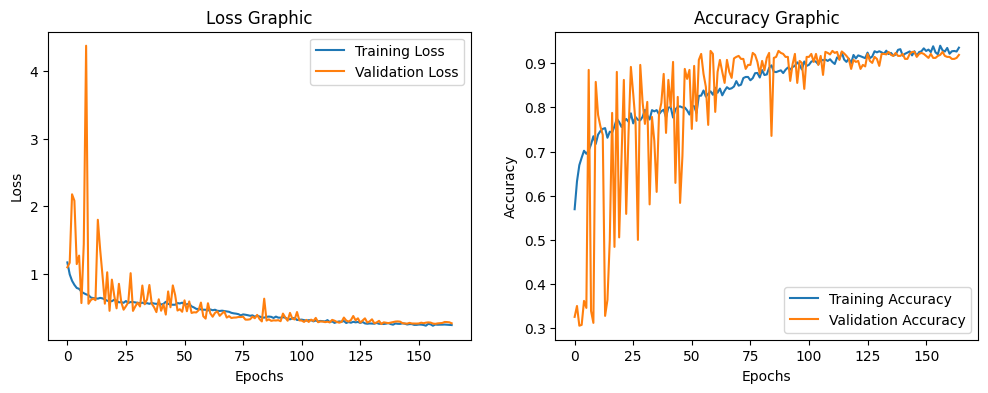

In [ ]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/pretrained", exist_ok=True)
met_vil.plot_training_history(history_pretrained, f"{results_dir}/pretrained", 'pre_training_adni_training_history.png')

### PREDIÇÃO VALIDAÇÃO PRE TREINO

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

2026-01-13 23:34:22.535811: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 4s:

  %reduce-window.95 = f32[2,52,65,54,4]{4,3,2,1,0} reduce-window(f32[2,156,195,160,4]{4,3,2,1,0} %broadcast.83, f32[] %constant.84), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x1_1x0_0}, to_apply=%region_1.91, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-13 23:34:26.287498: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 7.751743057s
Constant folding an instruction i

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       137
           1       0.97      0.91      0.94       305

    accuracy                           0.92       442
   macro avg       0.90      0.93      0.91       442
weighted avg       0.93      0.92      0.92       442



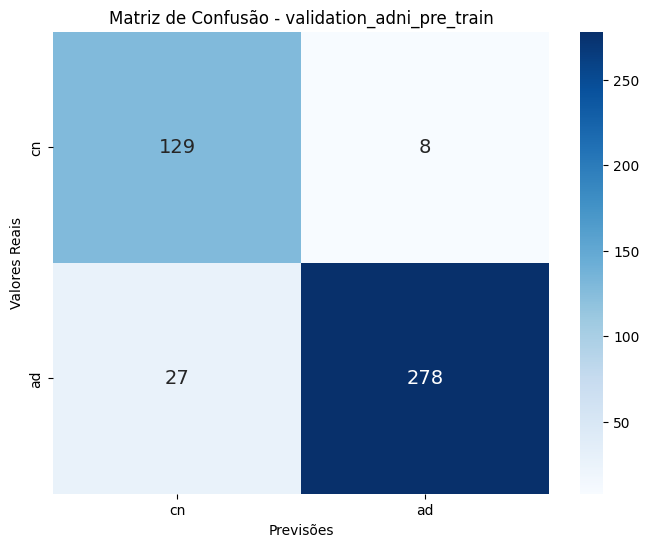

In [ ]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
val_pdf_path = os.path.join(f"{results_dir}/pretrained", "validation_adni_predictions_pre_train.pdf")
met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, ["cn", "ad"])

### PREDIÇÃO TESTE PRE TREINO

Passo 1: Coletando arquivos e definindo estratégia...
Total de 227 imagens planejadas.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/227
Progresso: 200/227
Concluído.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step

2026-01-13 23:35:32.237832: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=1,k13=0,k14=4,k18=0,k23=0} for conv (f16[3,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[3,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-13 23:35:32.242966: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.057084844s
Trying algorithm eng10{k2=1,k13=0,k14=4,k18=0,k23=0} for conv (f16[3,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[3,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

           0       0.66      0.95      0.78        73
           1       0.97      0.77      0.86       154

    accuracy                           0.82       227
   macro avg       0.81      0.86      0.82       227
weighted avg       0.87      0.82      0.83       227



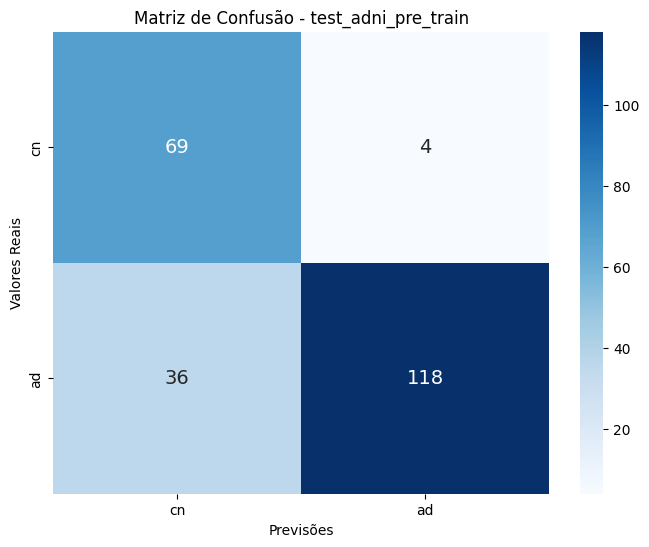

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [ ]:
test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
test_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_train.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, ["cn", "ad"])

# Transfer learning

In [ ]:
# LIMPAR DADOS
del train_images
del train_labels
del train_paths
del val_images
del val_labels
del val_paths
gc.collect()

4910

In [ ]:
# Experimento 1
train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
    fine_tunning_train_dir, 
    oasis_class_names, 
    augment=True, 
    augmentation_factor=1,      # 1 para 1
    include_intensity=False,    # Só Geometria
    transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
)

# # Experimento 2
# train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
#     fine_tunning_train_dir, 
#     oasis_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 3
# train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
#     fine_tunning_train_dir, 
#     oasis_class_names, 
#     augment=True, 
#     augmentation_factor=1,      # 1 para 1
#     include_intensity=True,     # Geometria + Intensidade
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 4
# train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
#     fine_tunning_train_dir, 
#     oasis_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=True,     # Geometria + Intensidade
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 5
# train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
#     fine_tunning_train_dir, 
#     oasis_class_names, 
#     augment=True, 
#     augmentation_factor=1,      # 1 para 1
#     include_intensity=False,    # Só Geometria
#     transform_probability=0.5   # 50% chance de transformar, 50% de manter original
# )

# # Experimento 6
# train_images_fine_tunning, train_labels_fine_tunning, train_paths_fine_tunning, class_labels_fine_tunning = proc_dados.load_nifti_data_balanced_preallocated(
#     fine_tunning_train_dir, 
#     oasis_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=0.5   # 50% chance de transformar, 50% de manter original
# )

print(f"N treino: {len(train_images_fine_tunning)}")

val_images_fine_tunning, val_labels_fine_tunning, val_paths_fine_tunning, _ = proc_dados.load_nifti_data_balanced_preallocated(
    fine_tunning_val_dir, 
    oasis_class_names, 
    augment=False
)

print(f"N validatio antes: {len(val_paths_fine_tunning)}")

val_images_fine_tunning, test_images_fine_tunning, val_labels_fine_tunning, test_labels_fine_tunning, val_paths_fine_tunning, test_paths_fine_tunning = train_test_split(
    val_images_fine_tunning, 
    val_labels_fine_tunning, 
    val_paths_fine_tunning, 
    train_size=0.6, 
    test_size=0.4, 
    random_state=42
)

print(f"N validation depois: {len(val_paths_fine_tunning)}")
print(f"N teste: {len(test_paths_fine_tunning)}")

Passo 1: Coletando arquivos e definindo estratégia...
Total de 164 imagens planejadas.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/164
Concluído.
N treino: 164
Passo 1: Coletando arquivos e definindo estratégia...
Total de 69 imagens planejadas.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Concluído.
N validatio antes: 69
N validation depois: 41
N teste: 28


In [ ]:
fase_atual = 2
print("--- INICIANDO FASE 2: FINE-TUNING ---")

# CARREGA O MODELO DA FASE 1
if not os.path.exists(PATH_PRETREINADO):
    raise FileNotFoundError(f"Modelo pré-treinado não encontrado em {PATH_PRETREINADO}. Rode a Fase 1 primeiro.")

print(f"Carregando pesos de: {PATH_PRETREINADO}")
base_model = load_model(PATH_PRETREINADO)

# --- CONGELAMENTO E ADAPTAÇÃO ---
# 1. Remover a camada de classificação antiga e adicionar uma nova (ADnetEx)
# Pega a saída da camada anterior à última
x = base_model.layers[-2].output 

# Adiciona nova camada de classificação inicializada aleatoriamente
predictions = layers.Dense(n_oasis_classes, activation='softmax', name='new_output')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

# 2. Congelar camadas iniciais (Freezing)
# Vamos congelar as primeiras 7 camadas (aprox. o primeiro bloco convolucional)
for layer in model.layers[:7]:
    layer.trainable = False
    print(f"Camada congelada: {layer.name}")

# 3. Recompilar
# Usar mesmo learning_rate do pre_treino
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                loss='binary_crossentropy', 
                metrics=['binary_accuracy'])

model.summary()

--- INICIANDO FASE 2: FINE-TUNING ---
Carregando pesos de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/fine_tunning_oasis/test_3/modelo_pretrained.keras
Camada congelada: input_layer
Camada congelada: conv3d
Camada congelada: batch_normalization
Camada congelada: leaky_re_lu
Camada congelada: average_pooling3d
Camada congelada: dropout
Camada congelada: conv3d_1


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 77,330 (302.07 KB)

 Non-trainable params: 1,080 (4.22 KB)

In [ ]:
batch_size = 10

steps_per_epoch = math.ceil(len(train_images_fine_tunning) / batch_size)
validation_steps = math.ceil(len(val_images_fine_tunning) / batch_size)

train_generator_fine_tunning = proc_dados.nifti_data_generator_3d(train_images_fine_tunning, train_labels_fine_tunning, batch_size)
val_generator_fine_tunning = proc_dados.nifti_data_generator_3d(val_images_fine_tunning, val_labels_fine_tunning, batch_size)

# Callbacks
csv_filename = 'log_treino_fase2.csv'
checkpoint_path = PATH_FINETUNED

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max')
]

In [ ]:
epochs = 100 # Fine-tuning geralmente requer menos épocas

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_fine_tunning = model.fit(
    train_generator_fine_tunning,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator_fine_tunning,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 2 por 100 épocas...
Epoch 1/100


2026-01-13 23:36:36.019629: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[10,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[10,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-13 23:36:36.389430: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.369922739s
Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[10,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[10,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, 

16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - binary_accuracy: 0.5472 - loss: 0.8719

2026-01-13 23:36:56.833532: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[4,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[4,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-13 23:36:56.881272: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.047842068s
Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[4,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[4,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - binary_accuracy: 0.5516 - loss: 0.8698

2026-01-13 23:37:11.538360: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=0,k13=1,k14=2,k18=0,k23=0} for conv (f16[1,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[1,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-13 23:37:11.573150: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.034835387s
Trying algorithm eng10{k2=0,k13=1,k14=2,k18=0,k23=0} for conv (f16[1,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[1,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - binary_accuracy: 0.6220 - loss: 0.8365 - val_binary_accuracy: 0.3659 - val_loss: 3.0184 - learning_rate: 5.0000e-04
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - binary_accuracy: 0.7317 - loss: 0.6223 - val_binary_accuracy: 0.3600 - val_loss: 3.0243 - learning_rate: 5.0000e-04
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - binary_accuracy: 0.7744 - loss: 0.5577 - val_binary_accuracy: 0.3800 - val_loss: 2.7376 - learning_rate: 5.0000e-04
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - binary_accuracy: 0.8049 - loss: 0.4801 - val_binary_accuracy: 0.4146 - val_loss: 2.7755 - learning_rate: 5.0000e-04
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - binary_accuracy: 0.8415 - loss: 0.4443 - val_binary_accuracy: 0.4146 - val_loss: 2.7816 - learning_rate: 5.0000e-04
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - binary_accuracy: 0.8232 - loss: 0.4811 - val_binary_accuracy: 0.4146 - val_loss: 2.9806 - learning_rate: 5.00

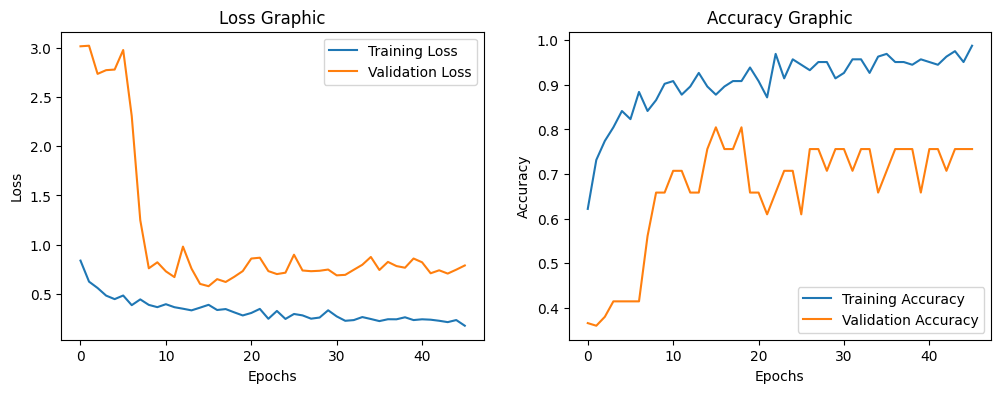

In [ ]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/final", exist_ok=True)
met_vil.plot_training_history(history_fine_tunning, f"{results_dir}/final", "fine_tunning_oasis_training_history.png")

### PREDIÇÃO VALIDAÇÃO

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        26
           1       0.63      0.80      0.71        15

    accuracy                           0.76        41
   macro avg       0.75      0.77      0.75        41
weighted avg       0.78      0.76      0.76        41



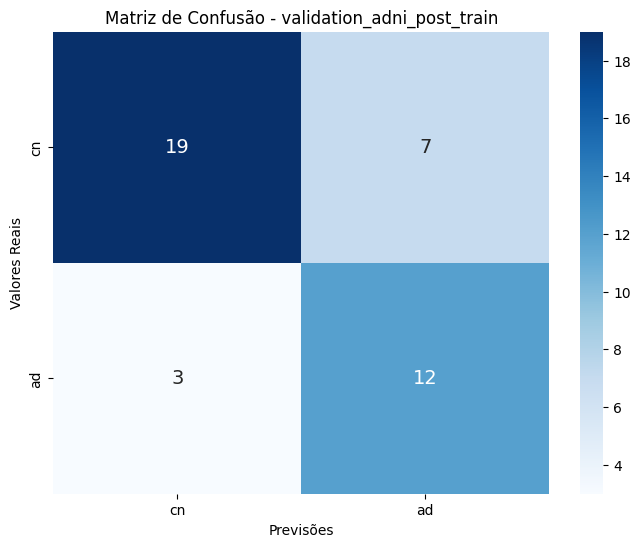

In [ ]:
# Realizar predições para dados do conjunto validação
val_pred_labels_post_train, val_true_labels_post_train, val_pred_post_train = met_vil.get_predictions(val_images_fine_tunning, val_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels_post_train, val_pred_labels_post_train, f"{results_dir}/final", 'validation_adni_post_train', ["cn", "ad"])

# Criar pdf com predições
val_pdf_path_post_train = os.path.join(f"{results_dir}/final", "validation_adni_predictions_post_train.pdf")
met_vil.create_pdf(val_paths_fine_tunning, val_images_fine_tunning, val_true_labels_post_train, val_pred_labels_post_train, val_pred_post_train, val_pdf_path_post_train, ["cn", "ad"])

### PREDIÇÃO TESTE

Passo 1: Coletando arquivos e definindo estratégia...
Total de 227 imagens planejadas.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/227
Progresso: 200/227
Concluído.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

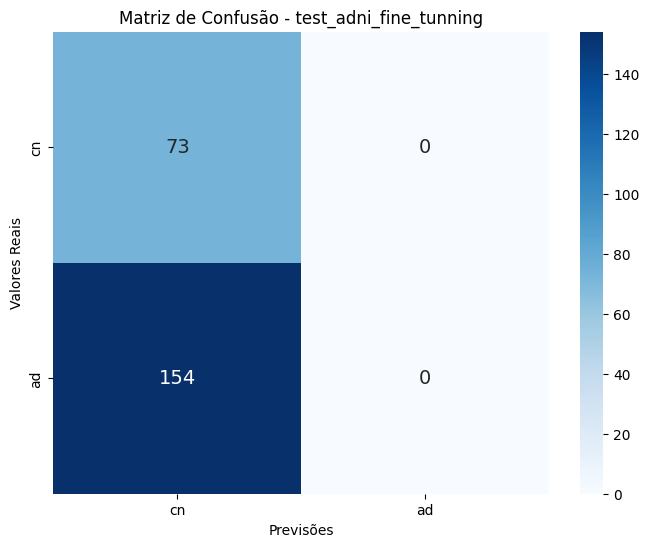

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/utils/metricas_e_visualizacao.py:119: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [ ]:
test_images_, test_labels_, test_paths_, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels_fine_tunning, test_true_labels_fine_tunning, test_pred = met_vil.get_predictions(test_images_, test_labels_, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels_fine_tunning, test_pred_labels_fine_tunning, f"{results_dir}/final", 'test_adni_fine_tunning', ["cn", "ad"])

# Criar pdf com predições
test_pdf_path_fine_tunning = os.path.join(f"{results_dir}/final", "test_adni_predictions_fine_tunning.pdf")
met_vil.create_pdf(test_paths_, test_images_, test_true_labels, test_pred_labels, test_pred, test_pdf_path, ["cn", "ad"])

### PREDIÇÃO OASIS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

           0       0.69      0.79      0.73        14
           1       0.75      0.64      0.69        14

    accuracy                           0.71        28
   macro avg       0.72      0.71      0.71        28
weighted avg       0.72      0.71      0.71        28



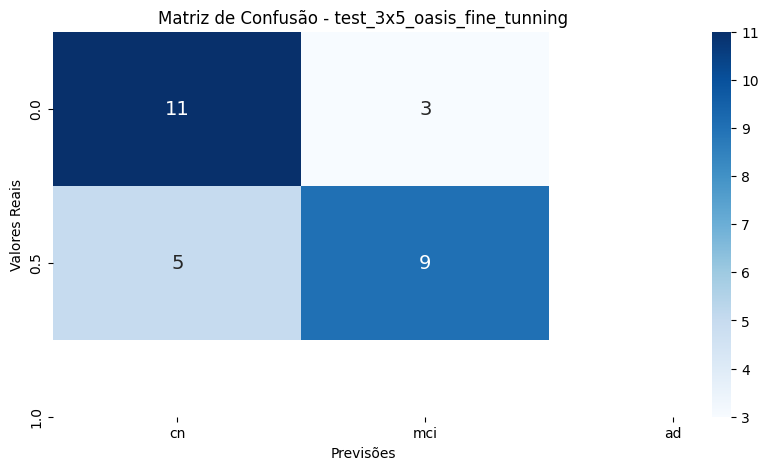

In [ ]:
# Realizar predições para dados do conjunto validação
oasis_pred_labels, oasis_true_labels, oasis_pred = met_vil.get_predictions(test_images_fine_tunning, test_labels_fine_tunning, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(oasis_true_labels, oasis_pred_labels, f"{results_dir}/final", 'test_oasis_fine_tunning')

# Obter matriz de confusão
cm_adjusted = confusion_matrix(oasis_true_labels, oasis_pred_labels)
met_vil.plot_custom_confusion_matrix(cm_adjusted, oasis_class_names, adni_class_names, f"{results_dir}/final", 'test_3x5_oasis_fine_tunning')

# # all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

# cm_3x3_adjusted = confusion_matrix(oasis_true_labels, gathered_oasis_pred)[0:3, 0:3]

# # Chame a nova função para plotar a matriz ajustada (3x5)
# plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_class_names, oasis_class_names, f"{results_dir}/final", 'test_3x3_oasis_fine_tunning')

# # Criar pdf com predições
oasis_pdf_path = os.path.join(f"{results_dir}/final", "test_oasis_predictions_fine_tunning.pdf")
# create_pdf(oasis_paths, oasis_images, oasis_true_labels, gathered_oasis_pred, oasis_pred, oasis_pdf_path, oasis_class_names)
met_vil.create_pdf(test_paths_fine_tunning, test_images_fine_tunning, oasis_true_labels, oasis_true_labels, oasis_pred, oasis_pdf_path, oasis_class_names)